# DH Intermediate Diagnostics — 20260722_v2000

Survivor-filtered honest-mean tail run (`model_predictions` ON). The intermediate
stage stress-tests the calibrated configs by **dropping the top-N storms by observed
deaths** — a config that only looks calibrated because of one giant storm (Nargis)
falls apart as N grows; a genuinely calibrated one stays near 1. The goal here is to
**lock the thresholds and narrow the 8 tail families** before the refined (decoupled-
covariate) stage.

_Cloned from `20260714_v1985/dh_intermediate_diagnostics.ipynb`; repointed at the
`20260722_v2000_intermediate` run and the lib `screening` module. OOS selects — do not
rank families by mechanism ahead of the numbers._

In [1]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from idd_tc_mortality.viz import screening as H

## Setup

Load the intermediate `dh_results.parquet` (one row per config, OOS metrics as
columns), the input parquet (storm×admin rows, row-aligned to the predictions), the
manifest (for `model_id` reconstruction), and the `model_predictions/` dir.

In [2]:
ROOT      = Path('/mnt/team/idd/pub/idd_tc_mortality')
EVAL_DATE = '20260722_v2000'
EVAL_DIR  = ROOT / '02-evaluate' / f'{EVAL_DATE}_intermediate'
INPUT_PATH = ROOT / '00-data' / EVAL_DATE / 'input.parquet'

RESULTS_PATH   = EVAL_DIR / 'dh_results.parquet'
MANIFEST_PATH  = EVAL_DIR / 'manifest.json'
MODEL_PRED_DIR = EVAL_DIR / 'model_predictions'

obs = pd.read_parquet(INPUT_PATH)
df_all = H.load_and_aggregate(RESULTS_PATH)
print(f'intermediate dh_results: {len(df_all):,} configs')
print(f'input.parquet:           {len(obs):,} storm x admin rows')
print(f'model_predictions:       {len(list(MODEL_PRED_DIR.glob("*.parquet"))):,} parquets')
print(f'tail families:           {sorted(df_all["tail_family"].dropna().unique())}')

intermediate dh_results: 1,134 configs
input.parquet:           1,903 storm x admin rows
model_predictions:       6,680 parquets
tail families:           ['gamma', 'gpd_cens', 'gpd_trunc', 'log_logistic_cens', 'log_logistic_trunc', 'lognormal', 'truncated_normal', 'weibull_mean']


## Calibration gate

First knob: keep configs whose full OOS pred/obs ratio is in-bounds. Look at the
distribution and set `RATIO_BOUNDS` on the **honest-mean** families rather than
inheriting the median-run bounds.

In [3]:
print(df_all['full_pred_obs_ratio_oos'].describe())

RATIO_BOUNDS = (0.1, 2.0)   # TUNE on the distribution above
ratio = df_all['full_pred_obs_ratio_oos']
calibrated = ratio.between(*RATIO_BOUNDS) & ratio.notna()
df = df_all[calibrated].reset_index(drop=True)
print(f'\n{len(df):,} of {len(df_all):,} configs pass full_pred_obs_ratio_oos in {RATIO_BOUNDS}')
print(df['threshold_quantile'].value_counts().sort_index())
print(df['tail_family'].value_counts())
print(pd.crosstab(df['tail_family'], df['threshold_quantile']))

count    1.118000e+03
mean     4.486996e+06
std      1.060338e+08
min      1.198809e-01
25%      3.375387e-01
50%      8.780465e-01
75%      2.683679e+00
max      2.508100e+09
Name: full_pred_obs_ratio_oos, dtype: float64

756 of 1,134 configs pass full_pred_obs_ratio_oos in (0.1, 2.0)
threshold_quantile
0.70    106
0.75    130
0.80    116
0.85     88
0.90    130
0.95    186
Name: count, dtype: int64
tail_family
truncated_normal      110
weibull_mean          110
log_logistic_trunc    104
lognormal             102
log_logistic_cens      92
gamma                  82
gpd_trunc              82
gpd_cens               74
Name: count, dtype: int64
threshold_quantile  0.70  0.75  0.80  0.85  0.90  0.95
tail_family                                           
gamma                 12    12    10    12    12    24
gpd_cens               6    14    10     6    16    22
gpd_trunc              6    18    12     6    16    24
log_logistic_cens     14    18    16     6    14    24
log_logistic_trunc  

## Reconstruct `model_id` (mid)

`dh_results` stores spec attributes but not the MD5 `model_id` used to name the
prediction parquets. Rebuild it from the manifest's IS component specs.

In [4]:
from idd_tc_mortality.cache import model_id as compute_model_id

manifest = json.loads(MANIFEST_PATH.read_text())
spec_lookup = {}
for cid, spec in manifest.items():
    if spec.get('fold_tag', 'is') != 'is':
        continue
    cov_str = json.dumps(spec.get('covariate_combo', {}), sort_keys=True)
    key = (spec.get('component'), spec.get('threshold_quantile'),
           spec.get('family'), spec.get('exposure_mode'), cov_str)
    spec_lookup[key] = spec

def _row_to_mid(row):
    q = row['threshold_quantile']
    s1 = spec_lookup[('s1',   None, row['s1_family'],   row['s1_exposure_mode'],   row['s1_cov'])]
    s2 = spec_lookup[('s2',   q,    row['s2_family'],   row['s2_exposure_mode'],   row['s2_cov'])]
    bk = spec_lookup[('bulk', q,    row['bulk_family'], row['bulk_exposure_mode'], row['bulk_cov'])]
    tl = spec_lookup[('tail', q,    row['tail_family'], row['tail_exposure_mode'], row['tail_cov'])]
    return compute_model_id(s1, s2, bk, tl)

df['mid'] = df.apply(_row_to_mid, axis=1)
test_mid = df['mid'].iloc[0]
print('mid attached. sample IS pred file exists:',
      (MODEL_PRED_DIR / f'{test_mid}_insample_predictions.parquet').exists())

mid attached. sample IS pred file exists: True


## Per-config prediction loaders

Prediction parquets carry only `predicted_rate`, row-aligned (by position) to
`input.parquet`. The loaders re-attach the input metadata (storm_id, deaths, exposed, year, basin).

In [5]:
def _join_input(pred_df):
    if len(pred_df) != len(obs):
        raise ValueError(f'pred rows {len(pred_df)} != input rows {len(obs)}')
    out = obs.copy()
    out['predicted_rate'] = pred_df['predicted_rate'].values
    return out

def load_is_pred(mid):
    return _join_input(pd.read_parquet(MODEL_PRED_DIR / f'{mid}_insample_predictions.parquet'))

def load_oos_pred(mid):
    frames = []
    for seed in range(5):
        p = MODEL_PRED_DIR / f'{mid}_oos_seed{seed}_predictions.parquet'
        if not p.exists():
            continue
        j = _join_input(pd.read_parquet(p))
        j['seed'] = seed
        frames.append(j)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

## Drop-top-N trimmed calibration ratio

For every calibrated config: aggregate predicted vs observed deaths per storm, drop
the top-N storms by **observed** deaths, and take the ratio of summed predicted to
summed observed over the survivors. Swept over N=[0,1,2,3,5] — a TUNE knob set to this vintage's death concentration (top-5 storms ≈ 80% of all deaths, so n=1,2,3 is the informative range; n≥10 strips ~90% of the signal and stops discriminating). IS and per-OOS-seed.

**Efficiency note:** each config's 6 parquets are read once; the N-sweep just re-slices
the per-storm aggregate in memory (the source notebook re-read all 6 for every N).

In [6]:
N_SWEEP = [0, 1, 2, 3, 5]   # TUNE: drop top-N storms by observed deaths; informative range for this vintage (top-5 storms ~80% of deaths, so n=1,2,3 is where it discriminates)

def _per_storm(pred):
    pred = pred.copy()
    pred['pred_deaths'] = pred['predicted_rate'] * pred['exposed']
    return (pred.groupby('storm_id', as_index=False)
                .agg(obs=('deaths', 'sum'), pred=('pred_deaths', 'sum'))
                .sort_values('obs', ascending=False).reset_index(drop=True))

def _trim_ratio(per_storm, n):
    keep = per_storm.iloc[n:]
    denom = keep['obs'].sum()
    return float(keep['pred'].sum() / denom) if denom > 0 else float('nan')

def trims_for_mid(mid):
    is_ps = _per_storm(load_is_pred(mid))
    oos = load_oos_pred(mid)
    oos_ps = [ _per_storm(sdf) for _, sdf in oos.groupby('seed') ] if not oos.empty else []
    out = {}
    for n in N_SWEEP:
        out[f'trim_n={n}_is'] = _trim_ratio(is_ps, n)
        seed_vals = [_trim_ratio(ps, n) for ps in oos_ps]
        out[f'trim_n={n}_oos_median'] = float(np.nanmedian(seed_vals)) if seed_vals else float('nan')
        out[f'trim_n={n}_oos_mean']   = float(np.nanmean(seed_vals))   if seed_vals else float('nan')
    return out

def _mid_trims(mid):
    return mid, trims_for_mid(mid)

# Fan configs over a PROCESS pool: each config reads its 6 parquets once and the
# per-storm aggregate is sliced per-N in memory. The per-config pandas work is
# GIL-bound, so a process pool (not thread) gives real parallelism; Linux fork lets
# workers inherit the loaders + obs + MODEL_PRED_DIR without pickling.
from concurrent.futures import ProcessPoolExecutor, as_completed
N_WORKERS = 12

records = {}
mids = df['mid'].tolist()
with ProcessPoolExecutor(max_workers=N_WORKERS) as pool:
    futures = [pool.submit(_mid_trims, m) for m in mids]
    for i, fut in enumerate(as_completed(futures), start=1):
        mid, out = fut.result()
        records[mid] = out
        if i % 200 == 0:
            print(f'  {i}/{len(mids)} configs')
rec_df = pd.DataFrame(records).T
print(f'done: {len(rec_df)} configs')

  200/756 configs
  400/756 configs
  600/756 configs
done: 756 configs


In [7]:
trim_df_median = rec_df[[f'trim_n={n}_oos_median' for n in N_SWEEP]].copy()
trim_df_mean   = rec_df[[f'trim_n={n}_oos_mean'   for n in N_SWEEP]].copy()
trim_df_is     = rec_df[[f'trim_n={n}_is'         for n in N_SWEEP]].copy()
# Summarize the 5 OOS CV seeds by median, matching load_and_aggregate's seed
# aggregation for the screening gate. NB: this median is ACROSS SEEDS ONLY --
# orthogonal to the tail mean-vs-median; predicted_rate is already the honest mean.
trim_df = trim_df_median

# Attach config attributes for the family/threshold views below.
attrs = df.set_index('mid')[['threshold_quantile', 'tail_family', 'tail_exposure_mode',
                             'bulk_family', 'bulk_exposure_mode', 's2_family', 's1_family']]

**What to look for:** configs near 1 at `trim_n=0` but far from 1 at `trim_n=25`
were only calibrated by the biggest storms. A robust config sits near log-ratio 0 in
*every* panel.

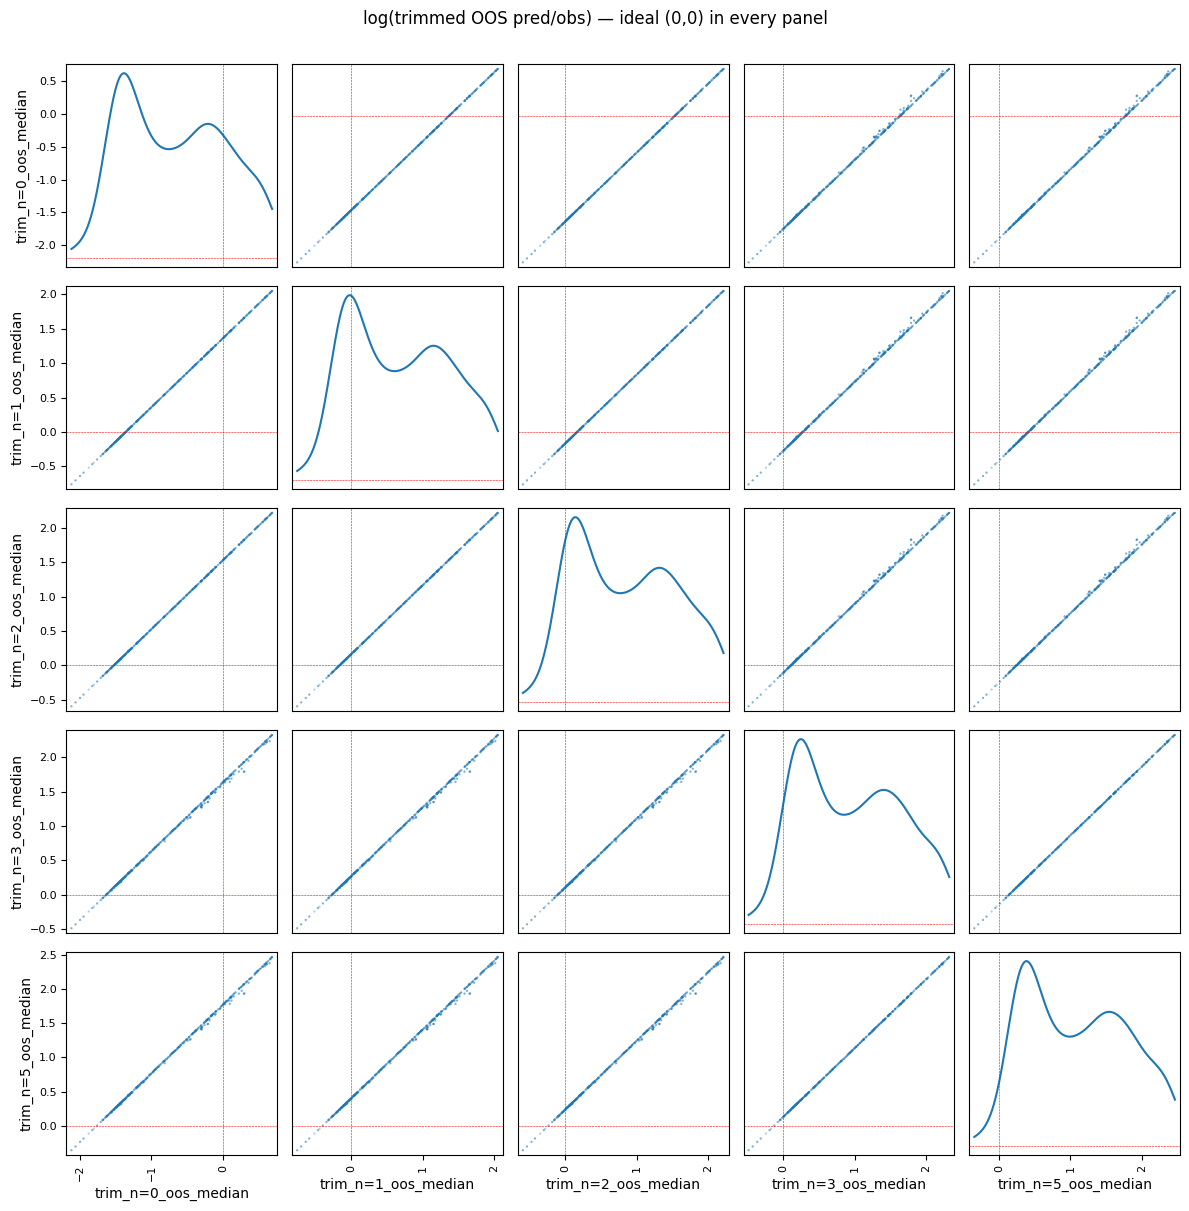

In [8]:
from pandas.plotting import scatter_matrix

log_trim = (trim_df.replace([np.inf, -np.inf], np.nan)
                   .clip(lower=1e-2, upper=1e3).apply(np.log))
axes = scatter_matrix(log_trim, figsize=(12, 12), diagonal='kde', alpha=0.35, s=10)
for r in axes:
    for ax in r:
        ax.axhline(0, color='red', ls='--', lw=0.4)
        ax.axvline(0, color='red', ls='--', lw=0.4)
plt.suptitle('log(trimmed OOS pred/obs) — ideal (0,0) in every panel', y=1.005)
plt.tight_layout(); plt.show()

## Per-tail-family view

The intermediate cull narrows the 8 honest tail families. Which families stay near 1
as the biggest storms are dropped, and which only calibrate on the extremes?

In [9]:
trim_attr = trim_df.join(attrs, how='left')
by_fam = trim_attr.groupby('tail_family')[list(trim_df.columns)].median().round(3)
print('median trimmed OOS pred/obs by tail family:')
print(by_fam)

median trimmed OOS pred/obs by tail family:
                    trim_n=0_oos_median  trim_n=1_oos_median  \
tail_family                                                    
gamma                             0.627                2.445   
gpd_cens                          0.554                2.160   
gpd_trunc                         0.506                1.973   
log_logistic_cens                 0.437                1.704   
log_logistic_trunc                0.480                1.872   
lognormal                         0.520                2.029   
truncated_normal                  0.313                1.220   
weibull_mean                      0.570                2.225   

                    trim_n=2_oos_median  trim_n=3_oos_median  \
tail_family                                                    
gamma                             2.890                3.214   
gpd_cens                          2.551                2.845   
gpd_trunc                         2.324                2.57

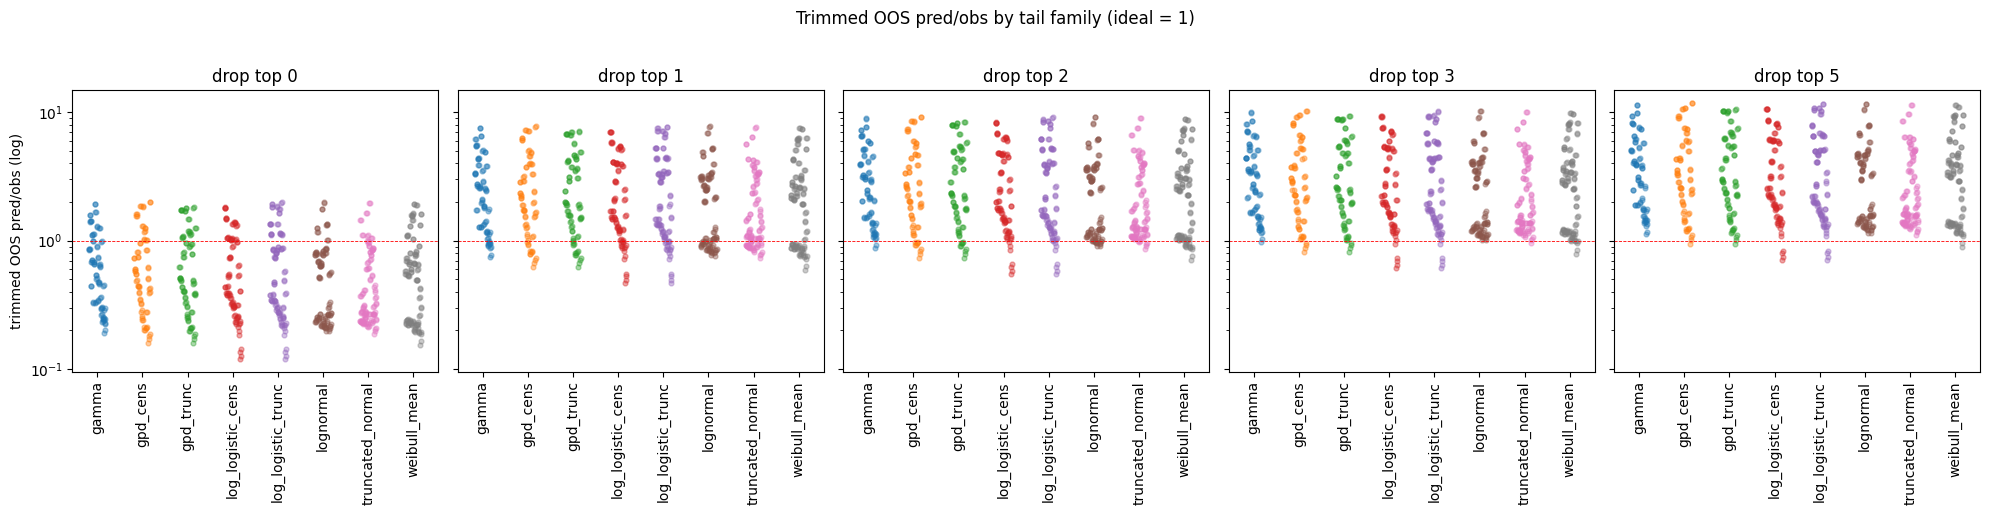

In [10]:
fams = sorted(trim_attr['tail_family'].dropna().unique())
fig, axes = plt.subplots(1, len(N_SWEEP), figsize=(4 * len(N_SWEEP), 5), sharey=True)
for ax, n in zip(axes, N_SWEEP):
    col = f'trim_n={n}_oos_median'
    for i, fam in enumerate(fams):
        vals = (trim_attr.loc[trim_attr['tail_family'] == fam, col]
                .replace([np.inf, -np.inf], np.nan).dropna())
        jitter = np.linspace(-0.18, 0.18, len(vals)) if len(vals) else []
        ax.scatter(np.full(len(vals), i) + jitter, vals, alpha=0.4, s=12)
    ax.axhline(1, color='red', ls='--', lw=0.6)
    ax.set_yscale('log'); ax.set_title(f'drop top {n}')
    ax.set_xticks(range(len(fams))); ax.set_xticklabels(fams, rotation=90)
axes[0].set_ylabel('trimmed OOS pred/obs (log)')
plt.suptitle('Trimmed OOS pred/obs by tail family (ideal = 1)', y=1.02)
plt.tight_layout(); plt.show()

## Progressive stability filter

Keep only configs whose OOS-median trimmed ratio stays in-bounds at **every** N — a
config kept only by Nargis fails here. Watch which thresholds and families survive.

In [11]:
lo, hi = 0.25, 2.0   # TUNE
stable = trim_df_median.copy()
for n in N_SWEEP:
    stable = stable[stable[f'trim_n={n}_oos_median'].between(lo, hi)]
print(f'{len(stable)} configs stable across all N in [{lo}, {hi}]')
kept = df[df['mid'].isin(stable.index)]
print(kept['threshold_quantile'].value_counts().sort_index())
print(kept['tail_family'].value_counts())

122 configs stable across all N in [0.25, 2.0]
threshold_quantile
0.70     8
0.75    11
0.80    24
0.85    26
0.90     4
0.95    49
Name: count, dtype: int64
tail_family
truncated_normal      29
log_logistic_trunc    21
lognormal             19
log_logistic_cens     17
gamma                 14
gpd_cens               9
gpd_trunc              9
weibull_mean           4
Name: count, dtype: int64


## Band-tightening attrition

Instead of one hand-picked band, sweep the lower bound `lo` (band `[lo, 1/lo]`, symmetric
in log around 1) and watch how many configs survive at EVERY N — split by threshold and
by tail family. The curve that collapses at the smallest `lo` is the most fragile: it
needs the widest tolerance to keep any config. Pass `normalize=True` to compare survival
RATES (removes the fact that some thresholds simply have more configs).

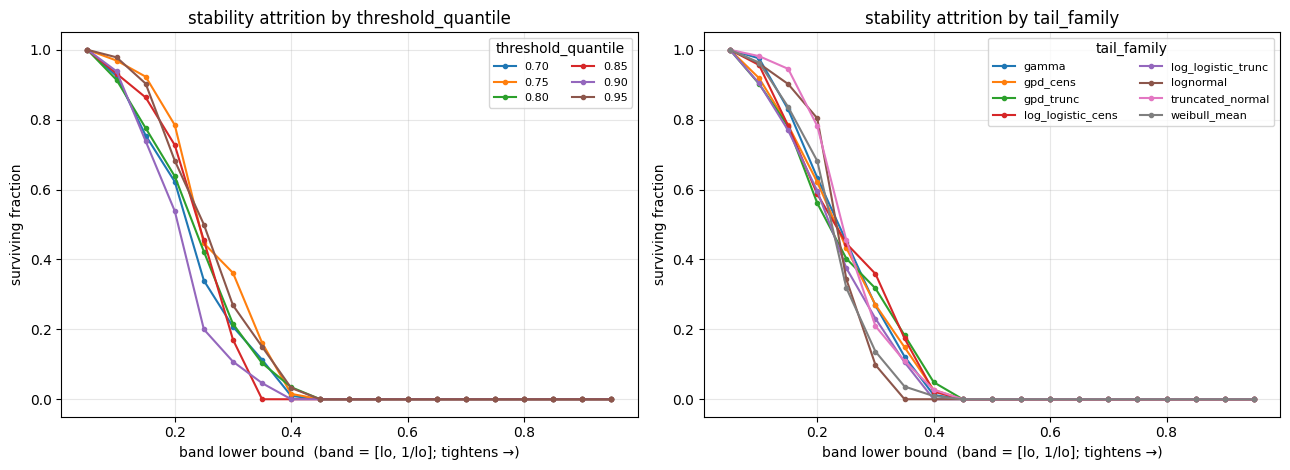

In [15]:
attrition = H.stability_attrition_curves(
    trim_df_median, attrs,
    n_cols=[f'trim_n={n}_oos_median' for n in N_SWEEP],
    group_cols=('threshold_quantile', 'tail_family'),
    normalize=True,   # True -> surviving FRACTION per level (removes base-rate size)
)

In [13]:
# Rank the stable set by worst-case deviation from 1 across all N.
clean = stable.replace([np.inf, -np.inf], np.nan).dropna()
log_dev = np.abs(np.log(clean))
ranked = (clean.assign(max_log_dev=log_dev.max(axis=1),
                       mean_log_dev=log_dev.mean(axis=1))
               .sort_values('max_log_dev')
               .join(attrs, how='left'))
print(ranked.head(30).round(3).to_string())

                                  trim_n=0_oos_median  trim_n=1_oos_median  trim_n=2_oos_median  trim_n=3_oos_median  trim_n=5_oos_median  max_log_dev  mean_log_dev  threshold_quantile         tail_family tail_exposure_mode   bulk_family bulk_exposure_mode s2_family s1_family
f8381752f8f3dacb2fd71e91915a3ecf                0.343                1.335                1.572                1.741                1.993        1.071         0.611                0.80            gpd_cens               free  scaled_logit               free     logit     logit
26d314b572cdc6832c489181426fe6b6                0.341                1.328                1.568                1.724                1.981        1.077         0.608                0.85               gamma               free  scaled_logit               free     logit     logit
65fb4287972f36c3ef0eb1b8490781e9                0.340                1.327                1.563                1.735                1.987        1.078         0.609     

## Decision — intermediate cull

**STOP HERE.** Record the cull below from the plots and tables above, then the refined
stage decouples covariates on the locked set.

- **Thresholds kept:** _fill in_
- **Tail families kept:** _fill in_
- **Exposure modes kept:** _fill in_

In [14]:
# CHOICE (fill in from the diagnostics above):
# INTERMEDIATE_THRESHOLDS   = [...]
# INTERMEDIATE_TAIL_FAMILIES = [...]
# INTERMEDIATE_EXPOSURES     = [...]